In [2]:
!pip install pyspark==3.0.3 matplotlib seaborn pandas scipy

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 209.1 MB 14 kB/s s eta 0:00:01            | 6.0 MB 2.3 MB/s eta 0:01:28███▋                 | 95.1 MB 78.9 MB/s eta 0:00:02
     |████████████████████████████████| 198 kB 19.7 MB/s eta 0:00:01
  Created wheel for pyspark: filename=pyspark-3.0.3-py2.py3-none-any.whl size=209435971 sha256=99de3f9881d3a715e65fec103316398e2573350d877824cf251017ab432e9d6c
  Stored in directory: /home/ubuntu/.cache/pip/wheels/7f/28/02/0373b4f55c817bebc0dfe467728642269180aecfc771cebd06
Successfully built pyspark


In [16]:
import os
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

# Запускаем Spark, выделяя ему RAM
spark = SparkSession.builder \
    .appName("TxtDataDriftDetection") \
    .config("spark.driver.memory", "8g") \
    .getOrCreate()

# Путь к локальной папке, где лежат ваши файлы .txt по 2 ГБ
local_txt_path = "/user/ubuntu/data/"

# Читаем текстовые файлы как CSV датасет
df_spark = spark.read \
    .format("csv") \
    .option("header", "false") \
    .option("comment", "#") \
    .option("inferSchema", "false") \
    .load(local_txt_path) \
    .toDF('transaction_id', 'tx_datetime', 'customer_id', 'terminal_id', 'tx_amount', 'tx_time_seconds', 'tx_time_days', 'tx_fraud', 'tx_fraud_scenario')

# Приводим типы к числовым и временным для анализа
df_spark = df_spark \
    .withColumn("tx_amount", F.col("tx_amount").cast("double")) \
    .withColumn("tx_fraud", F.col("tx_fraud").cast("int")) \
    .withColumn("tx_date", F.to_date(F.col("tx_datetime")))

print("Текстовые файлы успешно прочитаны и типизированы!")


Текстовые файлы успешно прочитаны и типизированы!


In [17]:
print("Расчет ежедневных метрик ...")
df_metrics_spark = df_spark \
    .groupBy("tx_date") \
    .agg(
        F.mean("tx_amount").alias("mean_amount"),
        F.expr("percentile_approx(tx_amount, 0.5)").alias("median_amount"), # Безопасный вызов медианы
        (F.sum("tx_fraud") / F.count("*") * 100).alias("fraud_rate")
    ) \
    .orderBy("tx_date")

# Забираем легкую агрегированную таблицу в Pandas
df_drift = df_metrics_spark.toPandas()

# Дропаем пустые даты, если в логах были совсем битые строки без времени
df_drift = df_drift.dropna(subset=['tx_date'])

print("📊 Агрегация завершена! Первые 5 дней:")
print(df_drift.head())


Расчет ежедневных метрик ...
📊 Агрегация завершена! Первые 5 дней:
      tx_date  mean_amount  median_amount  fraud_rate
0  2019-08-22    54.192616          45.37    5.464802
1  2019-08-23    54.240994          45.40    5.501254
2  2019-08-24    54.211864          45.40    5.466925
3  2019-08-25    54.235799          45.41    5.449080
4  2019-08-26    54.251088          45.41    5.453966


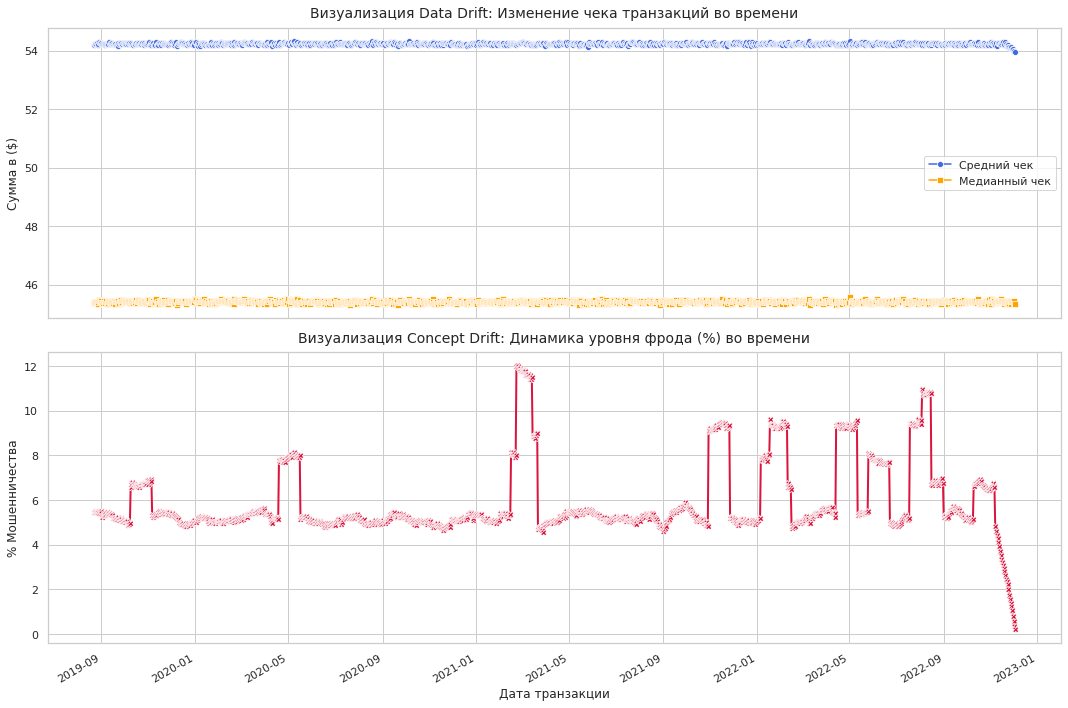

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# 1. Тренд среднего и медианного чека
sns.lineplot(data=df_drift, x='tx_date', y='mean_amount', marker='o', color='royalblue', label='Средний чек', ax=ax1)
sns.lineplot(data=df_drift, x='tx_date', y='median_amount', marker='s', color='orange', label='Медианный чек', ax=ax1)
ax1.set_title('Визуализация Data Drift: Изменение чека транзакций во времени', fontsize=14, pad=10)
ax1.set_ylabel('Сумма в ($)', fontsize=12)
ax1.legend()

# 2. Тренд изменения доли фрода
sns.lineplot(data=df_drift, x='tx_date', y='fraud_rate', marker='X', color='crimson', linewidth=2, ax=ax2)
ax2.set_title('Визуализация Concept Drift: Динамика уровня фрода (%) во времени', fontsize=14, pad=10)
ax2.set_xlabel('Дата транзакции', fontsize=12)
ax2.set_ylabel('% Мошенничества', fontsize=12)

plt.gcf().autofmt_xdate() # Наклоняем даты на оси X для читаемости
plt.tight_layout()
plt.show()


In [10]:
import numpy as np

# Считаем базовое среднее и стандартное отклонение (сигму) по всем дням
overall_mean = df_drift['mean_amount'].mean()
overall_std = df_drift['mean_amount'].std()

# Границы нормы
lower_bound = overall_mean - 3 * overall_std
upper_bound = overall_mean + 3 * overall_std

print("--- АНАЛИЗ ГРАНИЦ НОРМЫ ---")
print(f"Историческое среднее значение чека: {overall_mean:.2f} $")
print(f"Стандартное отклонение (сигма):     {overall_std:.2f} $")
print(f"Границы нормы для среднего чека:    [{max(0, lower_bound):.2f} $ ; {upper_bound:.2f} $]\n")

# Ищем дни, вылетевшие за рамки 3 сигм
anomalous_days = df_drift[(df_drift['mean_amount'] > upper_bound) | (df_drift['mean_amount'] < lower_bound)]

print("--- РЕЗУЛЬТАТЫ ПОИСКА АНОМАЛИЙ ---")
if not anomalous_days.empty:
    print(f"❌ Найдено аномальных дней: {len(anomalous_days)}")
    print("Эти даты выбиваются из общего распределения тренда:\n")
    for idx, row in anomalous_days.iterrows():
        deviation = (row['mean_amount'] - overall_mean) / overall_std
        print(f"📅 Дата: {row['tx_date']} | Средний чек: {row['mean_amount']:.2f} $ | Отклонение: {deviation:+.1f} сигм")
else:
    print("✅ Аномальных дней не обнаружено! Колебания находятся в пределах математической нормы.")


--- АНАЛИЗ ГРАНИЦ НОРМЫ ---
Историческое среднее значение чека: 54.23 $
Стандартное отклонение (сигма):     0.03 $
Границы нормы для среднего чека:    [54.13 $ ; 54.33 $]

--- РЕЗУЛЬТАТЫ ПОИСКА АНОМАЛИЙ ---
❌ Найдено аномальных дней: 9
Эти даты выбиваются из общего распределения тренда:

📅 Дата: 2022-11-24 | Средний чек: 54.12 $ | Отклонение: -3.4 сигм
📅 Дата: 2022-11-25 | Средний чек: 54.11 $ | Отклонение: -3.6 сигм
📅 Дата: 2022-11-26 | Средний чек: 54.10 $ | Отклонение: -4.0 сигм
📅 Дата: 2022-11-27 | Средний чек: 54.07 $ | Отклонение: -4.8 сигм
📅 Дата: 2022-11-29 | Средний чек: 54.06 $ | Отклонение: -5.3 сигм
📅 Дата: 2022-11-30 | Средний чек: 54.05 $ | Отклонение: -5.5 сигм
📅 Дата: 2022-12-01 | Средний чек: 53.99 $ | Отклонение: -7.4 сигм
📅 Дата: 2022-12-02 | Средний чек: 54.00 $ | Отклонение: -7.0 сигм
📅 Дата: 2022-12-03 | Средний чек: 53.94 $ | Отклонение: -8.7 сигм


In [18]:
# Укажите путь на вашем компьютере для сохранения чистого Parquet
local_output_parquet_path = "/user/ubuntu/data/cleaned_output_parquet"

# Список аномальных дат, который выдало правило 3 сигм
bad_dates = [
    "2022-11-24", "2022-11-25", "2022-11-26", "2022-11-27", 
    "2022-11-29", "2022-11-30", "2022-12-01", "2022-12-02", "2022-12-03"
]

print("Применяем правила фильтрации и исправления 'плохих' данных...")
# 1. Удаляем пропуски в критических идентификаторах и датах
# 2. Очистка аномалий чека (отрицательные преобразуем в модуль, пустые в 0.0)
# 3. Заполняем пустые строки фрода нулями (безопасное дефолтное значение)

df_cleaned = df_spark \
    .withColumn("tx_amount", F.col("tx_amount").cast("double")) \
    .withColumn("tx_fraud", F.col("tx_fraud").cast("int")) \
    .withColumn("tx_fraud_scenario", F.col("tx_fraud_scenario").cast("int")) \
    .withColumn("tx_date", F.to_date(F.col("tx_datetime"))) \
    \
    .filter(~F.col("tx_date").isin(bad_dates)) \
    \
    .dropna(subset=["transaction_id", "customer_id", "tx_datetime", "tx_date"]) \
    \
    .withColumn("tx_amount", F.when(F.col("tx_amount") < 0, F.abs(F.col("tx_amount")))
                             .otherwise(F.coalesce(F.col("tx_amount"), F.lit(0.0)))) \
    \
    .fillna({"tx_fraud": 0, "tx_fraud_scenario": 0})

print(f"Запуск локальной конвертации в Parquet с разбивкой по датам (исключено {len(bad_dates)} дней)...")
df_cleaned.write \
    .mode("overwrite") \
    .format("parquet") \
    .option("compression", "snappy") \
    .partitionBy("tx_date") \
    .save(local_output_parquet_path)

print(f"🚀 Пайплайн успешно завершен! Чистый Snappy-Parquet сохранен: {local_output_parquet_path}")


Применяем правила фильтрации и исправления 'плохих' данных...
Запуск локальной конвертации в Parquet с разбивкой по датам (исключено 9 дней)...
🚀 Пайплайн успешно завершен! Чистый Snappy-Parquet сохранен: /user/ubuntu/data/cleaned_output_parquet


In [ ]:
hadoop distcp /user/ubuntu/data/cleaned_output_parquet s3a://otus-bucket-tyurin-parq-b1gboro5hsu0aq2dmmfl/